In [ ]:
#Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
#rfm dataset and creating Folder

In [ ]:
rfm = pd.read_csv("rfm.csv")
rfm_scaled = pd.read_csv("rfm_scaled.csv")
os.makedirs("results/PCA_Output", exist_ok=True)

In [ ]:
#K-Means Clustering

In [10]:
def kmeans_clustering(data, k):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(data)
    return labels, model
labels_kmeans, model = kmeans_clustering(rfm_scaled, k=4)

In [ ]:
#PCA Visualization

In [ ]:
def pca_visualization(data, labels):



    # 2D PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    plt.figure()
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("PCA Cluster Visualization (2D)")
    plt.savefig("results/PCA_Output/pca_2d.png")
    plt.show()

    # 3D PCA 
    pca_3d = PCA(n_components=3)
    reduced_3d = pca_3d.fit_transform(data)


    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(reduced_3d[:, 0], reduced_3d[:, 1], reduced_3d[:, 2], c=labels)

    ax.set_title("PCA Cluster Visualization (3D)")
    plt.savefig("results/PCA_Output/pca_3d.png")
    plt.show()

In [ ]:
#Tsne_Visualization

In [17]:
def tsne_visualization(data, labels):
    
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(data)

    plt.figure()
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title("t-SNE Cluster Visualization (2D)")
    plt.savefig("results/PCA_Output/tsne_2d.png")
    plt.show()

In [ ]:
#Implementation

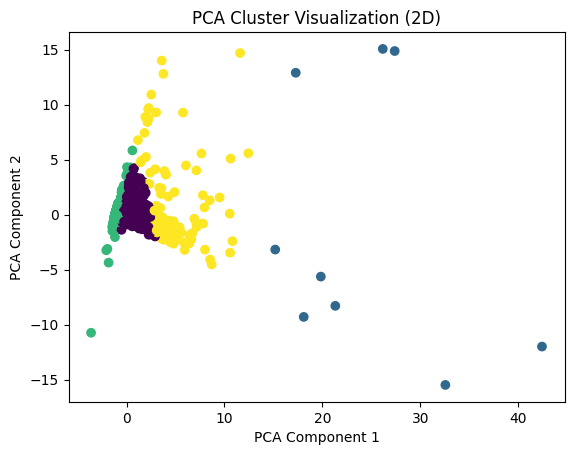

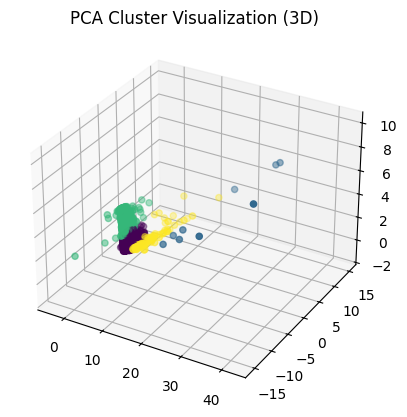

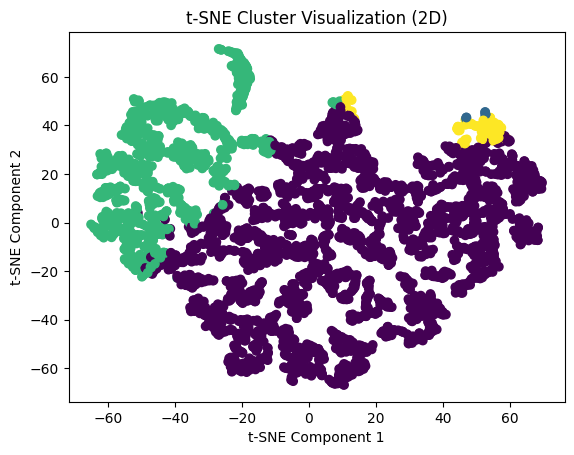

In [18]:
pca_visualization(rfm_scaled, labels_kmeans)
tsne_visualization(rfm_scaled, labels_kmeans)

In [ ]:
#Bar Graph

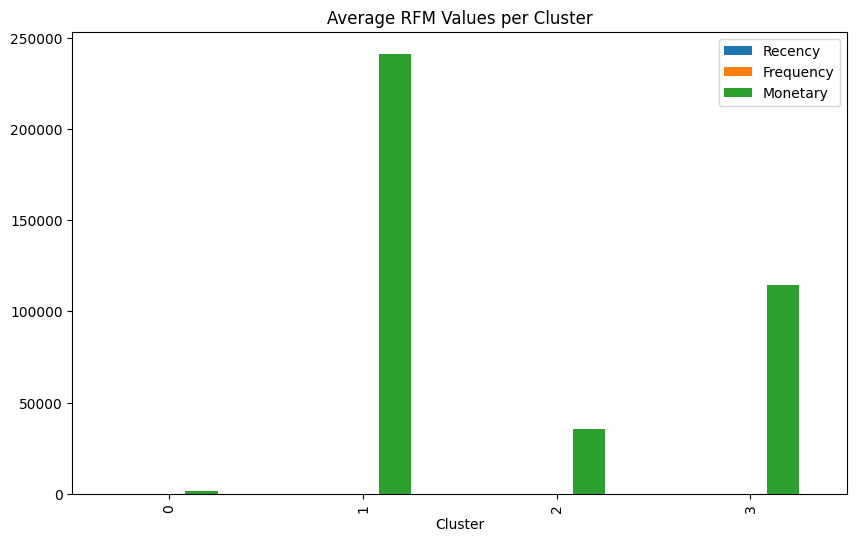

In [9]:
cluster_summary = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

cluster_summary.plot(kind="bar", figsize=(10,6))
plt.title("Average RFM Values per Cluster")
plt.savefig("results/PCA_Output/Bar_Graph.png")
plt.show()